In [19]:
import scipy.io
from scipy.io import loadmat
import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
#from google.colab import drive
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
import warnings
import time 
warnings.filterwarnings('ignore')
#colab
#drive.mount('/content/drive')
#file_path = "/content/drive/MyDrive/DREAMER.mat"
#mat = scipy.io.loadmat(file_path)

mat=loadmat('DREAMER.mat')
# 실제 피실험자들의 데이터가 담긴 핵심 배열 추출 후, 총 피험자 수 파악
dreamer_subjects = mat['DREAMER'][0, 0]['Data'][0]

num_subjects = dreamer_subjects.shape[0]
print(f'피험자수:{num_subjects}')

# 1. 설정 및 PSD 함수

# 초당 데이터 포인트 수 (128Hz)
fs = 128
# 분석에 사용되는 EEG 채널의 총 개수
num_channels = 14
# 표준 뇌파 대역(Band) 정의: 이름과 해당 주파수 범위(Hz)를 딕셔너리로 설정
bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45)}
# 채널 이름을 'ch1', 'ch2' 등으로 자동 생성 (총 14개)
#channel_names = [f'ch{i+1}' for i in range(num_channels)]

# 단일 EEG 신호(signal)를 입력받아 각 주파수 대역의 파워 스펙트럼 밀도(PSD)를 계산하는 함수
def compute_band_power(signal, sf=fs, bands=bands):
    nperseg = min(sf * 2, len(signal))  # PSD 계산(Welch's method) 시 한 세그먼트에 사용할 데이터 포인트 수

    # 신호 길이가 nperseg(여기서는 128)보다 짧으면 유효한 PSD 계산이 불가능, 이 경우 모든 파워를 0으로 반환하고 NaN을 방지
    if nperseg < 128: return {band: 0.0 for band in bands}, 0.0, 0.0, 0.0

    # Welch's method를 사용하여 PSD를 계산 (f: 주파수 벡터 (Frequency array), Pxx: 파워 스펙트럼 밀도 (Power Spectral Density array))
    f, Pxx = welch(signal, sf, nperseg=nperseg)
    band_powers = {}
    alpha_power = 0.0; beta_power = 0.0; theta_power = 0.0
    for band, (low, high) in bands.items(): #정의된 뇌파 대역을 반복하며 각 대역의 파워를 합산
      idx = np.logical_and(f >= low, f <= high)
      power = np.sum(Pxx[idx])
      band_powers[band] = power

      if band == 'alpha': alpha_power = power
      if band == 'beta': beta_power = power
      if band == 'theta': theta_power = power
    return band_powers, theta_power, alpha_power, beta_power

# --- 2. 특징 추출 및 레이블링 (df_final 생성) ---
# (Subject 반복 -> Baseline 보정 -> 14개 채널 통계/PSD/비율 특징 추출 -> df 생성 -> Arousal 3점 NaN 처리)
# 이 단계에서 Theta/Alpha, Beta/Alpha 비율에서 NaN이 생성된다. (Alpha Power가 0일 때)

# 최종 DataFrame 저장용 리스트
rows = []
start=time.time()
# 피험자 반복 및 특징 추출
# 전체 피험자 수(num_subjects)만큼 루프를 돌며 각 피험자 데이터를 처리
for subj_idx in range(num_subjects):
    subject = dreamer_subjects[subj_idx] # 현재 피험자의 모든 데이터 구조체(EEG, 레이팅 등)를 추출
    subj_id = f"S{subj_idx+1}"  # 피험자 ID (예: 'S1', 'S2'...)를 생성 (LOSO-CV 그룹 식별자로 사용)

    eeg_outer = subject['EEG'][0,0]

    # 피험자의 감정 평가 점수(Valence, Arousal)를 1차원 배열로 추출
    valence_ratings = subject['ScoreValence'][0,0].flatten()
    arousal_ratings = subject['ScoreArousal'][0,0].flatten()

    # Baseline(자극 전)과 Stimuli(자극 중) EEG 데이터가 담긴 셀 배열을 추출
    baseline_cell_array = eeg_outer['baseline'][0,0]
    stimuli_cell_array  = eeg_outer['stimuli'][0,0]

    for stim_idx in range(18):  # 각 피험자가 시청한 18개의 자극(영상)에 대해 루프 돌리기
        baseline = baseline_cell_array[stim_idx][0]
        stimuli  = stimuli_cell_array[stim_idx][0]

        # Time Series 길이 보정 로직
        min_len = min(stimuli.shape[0], baseline.shape[0])
        corrected_data = stimuli[:min_len, :] - baseline[:min_len, :]

        # * 특징 추출 *
        feats = {}
        for ch_idx in range(num_channels):
            ch_signal = corrected_data[:, ch_idx]
            ch_key = f'ch{ch_idx+1}'

            feats[f'{ch_key}_mean'] = np.mean(ch_signal) # 신호 평균값
            feats[f'{ch_key}_std'] = np.std(ch_signal)   # 신호 표준편차값
            feats[f'{ch_key}_var'] = np.var(ch_signal)   # 신호 분산값
            feats[f'{ch_key}_min'] = np.min(ch_signal)   # 신호 최솟값
            feats[f'{ch_key}_max'] = np.max(ch_signal)   # 신호 최댓값

            # 주파수 영역 파워 특징 (Band Power) 계산
            band_powers, theta_power, alpha_power, beta_power = compute_band_power(ch_signal)

            for band_name, power in band_powers.items():
                 feats[f'{ch_key}_{band_name}'] = power

            # 뇌파 비율 특징 (Ratio Features) 계산
            theta_ratio = theta_power / alpha_power if alpha_power > 0 else 0 # theta/alpha 비율 계산, alpha_power가 0인 경우 NaN 대신 0을 할당
            beta_ratio = beta_power / alpha_power if alpha_power > 0 else 0 # beta/alpha 비율 계산 (스트레스/각성 지표), alpha_power가 0인 경우 NaN 대신 0을 할당

            feats[f'{ch_key}_theta/alpha'] = theta_ratio
            feats[f'{ch_key}_beta/alpha'] = beta_ratio

        # --- 감정 레이블 및 식별자 추가 ---
        feats['valence'] = valence_ratings[stim_idx] # 피험자의 주관적인 Valence(쾌/불쾌) 점수를 저장
        feats['arousal'] = arousal_ratings[stim_idx] # 피험자의 주관적인 Arousal(흥분/이완) 점수를 저장
        feats['subject'] = subj_id # 피험자 ID를 저장

        rows.append(feats)
end=time.time()

print(f'피험자 특징추출 시간: {end-start:.3f}')


# DataFrame 변환 및 스트레스 레이블링
# 'arousal' 점수를 사용하여 스트레스 레이블(0 또는 1)을 생성
df = pd.DataFrame(rows)
# 1. Arousal >= 4: 스트레스 (1)
# 2. Arousal <= 2: 비스트레스 (0)
# 3. Arousal = 3: 판단 보류 (NaN)
df['Stress_Label'] = np.where(df['arousal'] >= 4, 1, np.where(df['arousal'] <= 2, 0, np.nan))
# 'Stress_Label'이 NaN인 행(Arousal 3점 데이터)을 제거하여 최종 훈련/평가 데이터를 준비
df_final = df.dropna(subset=['Stress_Label']).copy()  



# --- Subject-wise Baseline 정규화 ---
X_features = [col for col in df_final.columns if col.startswith('ch')]
X_raw = df_final[X_features]
y = df_final['Stress_Label'].values
groups = df_final['subject'].values

# 피험자별 '비스트레스(0)' 상태의 평균과 표준편차 계산
# 비스트레스 상태(Stress_Label == 0, Arousal 1 또는 2점) 데이터만 필터링
baseline_df = df_final[df_final['Stress_Label'] == 0]
# 필터링된 데이터에서 피험자별(groupby('subject'))로 각 특징의 평균과 표준편차를 계산
# 이 통계량(baseline_stats)이 각 피험자의 기준선이 된다.
baseline_stats = baseline_df.groupby('subject')[X_features].agg(['mean', 'std'])

# * 정규화 함수 정의 *
def apply_baseline_normalization(row):
    subj_id = row['subject']
    try:
        # 계산된 baseline_stats에서 현재 피험자의 평균과 표준편차 가져오기
        subj_stats = baseline_stats.loc[subj_id]
        mu = subj_stats.loc[:, 'mean']
        sigma = subj_stats.loc[:, 'std']
    except KeyError:
        # Baseline 데이터(Arousal 1, 2점)가 없는 피험자 처리 (일반 스케일링으로 대체 가능)
        return pd.Series(np.nan, index=X_features)

    # 0 나누기 방지 로직 (표준편차가 0이면 1e-6으로 대체)
    sigma_safe = sigma.mask(sigma == 0, 1e-6)

    # Z-score 정규화 공식 적용: (특징 값 - 피험자 기준선 평균) / 피험자 기준선 표준편차
    normalized_features = (row[X_features] - mu) / sigma_safe
    return normalized_features

# df_final의 모든 행에 정규화 함수를 적용
X_normalized = df_final.apply(apply_baseline_normalization, axis=1)

# X_final_normalized는 이 코드의 결과물로, 이후 모든 모델 훈련의 X로 사용
X_final_normalized = X_normalized.values


# --- 결측치 처리: Median 방식(median 방식은 모델 7부터 사용) ---
# LOSO에서는 매 fold마다 '훈련 데이터'만 보고 median을 구해야 함.
# 이렇게 구한 median으로 훈련·테스트 둘 다 NaN을 채워서 데이터 누수를 막는다.
# 이렇게 하는 이유 : 테스트 데이터를 보고 median을 구해버리면 테스트 정보가 훈련 과정에 섞여버림.

print("\n--- 전처리 요약 ---")
print("1. EEG Time Series에서 Baseline 보정 적용")
print(f"2. 14개 채널에 대한 12개 피처 추출 (총 {len(X_features)}개)")
print("3. Arousal 3점 데이터는 레이블링에서 제외 (NaN)")
print("4. 피험자별 '비스트레스' 데이터를 기준으로 Baseline 정규화 적용")
print("5. 훈련 시, Ratio 피처의 잔여 NaN을 **훈련 데이터의 중앙값(Median)**으로 대체")
# LOSO-CV 루프 내부에서 수행
# 훈련 데이터의 Median 값으로 훈련/테스트 데이터의 NaN 대체
# Ratio 피처 포함, Median imputation은 RFE/피처 선택 전과 후 모두 적용


# --- 공통 설정 ---
logo = LeaveOneGroupOut()
N_FEATURES_TO_SELECT_20 = 20 # 최적 피처 수 20개
N_FEATURES_TO_SELECT_25 = 25 # 25개 시도
# RFE가 특징의 중요도를 평가할 때 내부적으로 사용할 기본 모델 (Logistic Regression 사용)
rfe_base_model = LogisticRegression(max_iter=5000, solver='liblinear', random_state=42)
results = []


# --- LOSO-CV 실행 함수 정의 ---
def run_loso_test(X, y, groups, model, strategy_name, n_features=None, imputer_strategy='constant', fill_value=0):
    accuracies = []
    y_true_all = []
    y_pred_all = []
    y_scores = []

    # Imputer 설정 (NaN 대체 객체 설정), # imputer_strategy='median'이면 SimpleImputer(strategy='median') 사용
    if imputer_strategy == 'constant':
        imputer = SimpleImputer(strategy='constant', fill_value=fill_value)
    else: # median
        imputer = SimpleImputer(strategy=imputer_strategy)

    
    # ----- LOSO-CV 시작 -----
    for train_index, test_index in logo.split(X, y, groups=groups):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # 1. NaN 처리
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)

        X_train_final, X_test_final = X_train_imputed, X_test_imputed

        # 2. RFE 적용 (중요한 피쳐 구하기)
        if n_features is not None:
            # RFE도 fold마다 훈련 데이터 기준으로 새로 피팅 → 누수 방지
            rfe_selector = RFE(estimator=rfe_base_model, n_features_to_select=n_features, step=1)
            X_train_final = rfe_selector.fit_transform(X_train_imputed, y_train)
            X_test_final = rfe_selector.transform(X_test_imputed)

        # 3. 모델 훈련 및 평가
        model.fit(X_train_final, y_train)
        y_pred = model.predict(X_test_final)
        try:
            y_score = model.predict_proba(X_test_final)[:, 1]
        except AttributeError:
            # 확률을 제공하지 않는 모델의 경우 NaN으로 채워 다음 단계의 에러 방지
            y_score = np.full_like(y_test, np.nan, dtype=float)

        
        accuracy = accuracy_score(y_test, y_pred)
        
        accuracies.append(accuracy)
        y_true_all.append(y_test)
        y_pred_all.append(y_pred)
        y_scores.append(y_score)

    y_true = y_true_all
    y_pred = y_pred_all
        

    # ----- Fold 결과 평균 -----
    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    results.append({
        'Strategy': strategy_name,
        'Accuracy': f'{avg_acc:.4f}',
        'Std Dev': f'{std_dev:.4f}',
        'Features': n_features if n_features is not None else X.shape[1]
    })
    print(f"[{strategy_name}] Acc: {avg_acc:.4f}, Std: {std_dev:.4f}")
    return avg_acc, y_true, y_pred, y_scores

# =======================================================
# 1. LOSO(로지스틱)만 했을 때 (Baseline)
# =======================================================
start=time.time()
model_basic = LogisticRegression(max_iter=5000, solver='liblinear', random_state=42)
run_loso_test(X_final_normalized, y, groups, model_basic, "1. Baseline (LogReg)", imputer_strategy='constant')
end=time.time()
print(f'--1. LOSO(로지스틱) 걸린시간--: {end-start:.3f}')
# =======================================================
# 2. PCA 사용 후 LOSO(로지스틱) (피쳐 30개)
# =======================================================
start=time.time()
N_PCA = 30
pca = PCA(n_components=N_PCA)
imputer = SimpleImputer(strategy='constant', fill_value=0)

X_imputed = imputer.fit_transform(X_final_normalized)
X_pca = pca.fit_transform(X_imputed)

# PCA 적용 후 LOSO-CV 실행
run_loso_test(X_pca, y, groups, model_basic, "2. 로지스틱 + PCA (30)", imputer_strategy='constant')

end=time.time()
print(f'--2. PCA 사용 후 LOSO(로지스틱) 걸린시간--: {end-start:.3f}')
# =======================================================
# 3. 로지스틱을 SVM으로 바꿈 (C=1, RBF, Full Feats(168개))
# =======================================================
start=time.time()
model_svm_rbf_full = SVC(kernel='rbf', C=1, gamma='auto', random_state=42)
run_loso_test(X_final_normalized, y, groups, model_svm_rbf_full, "3. SVM (Full Feats)")
end=time.time()
print(f'--3. 로지스틱을 SVM으로 바꾼후 걸린시간--: {end-start:.3f}')
# =======================================================
# ===================Grid Search=========================
# =======================================================


# =======================================================
#       3.5. RFE (20 Feats) 기반 Grid Search 실행
# =======================================================
print("\n" + "="*80)
print(f"RFE로 선택된 {N_FEATURES_TO_SELECT_20}개 피처 기반 최적 파라미터 탐색")
print("="*80)

# Grid Search를 위한 임퓨터 설정
start=time.time()
imputer_grid = SimpleImputer(strategy='median')

# kernel: 커널 타입, C: SVM 규제 파라미터, gamma: RBF/Poly 커널 파라미터, degree: Poly 커널 차수
param_grid = {
    'C': [1, 10, 100],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3],
    'gamma': ['scale', 'auto']
}

# 1. LOSO-CV의 첫 번째 훈련 데이터를 추출
first_fold = next(logo.split(X_final_normalized, y, groups=groups))
train_index, _ = first_fold

X_train_raw = X_final_normalized[train_index]
y_train = y[train_index]

# 2. 훈련 데이터 NaN 처리 (median으로 대체)
X_train_imputed = imputer_grid.fit_transform(X_train_raw)

# 3. RFE 실행: LogisticRegression 기반으로 최적 피처 20개 선택 (선형회귀 선택 이유 : 모델의 coef_(가중치)을 이용해서 중요도 판단)
rfe_selector = RFE(estimator=rfe_base_model, n_features_to_select=N_FEATURES_TO_SELECT_20, step=1)
rfe_selector.fit(X_train_imputed, y_train)

# 4. 선택된 20개 피처만 추출
X_train_20_feats = rfe_selector.transform(X_train_imputed)
print(f"   -> RFE로 {X_train_20_feats.shape[1]}개 피처 선택")

# 5. Grid Search 설정 및 실행 (내부 CV 5-Fold 사용)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)
grid_model = SVC(random_state=42)

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv_inner,
    n_jobs=1,
    verbose=1
)

# Grid Search 실행
grid_search.fit(X_train_20_feats, y_train)

# 6. 최적 파라미터 출력
best_params = grid_search.best_params_
print(f"\n RFE 20개 피처 기반 최적 파라미터: {best_params}")
print(f"   최적 정확도 (Inner CV): {grid_search.best_score_:.4f}")

# 베스트 파라미터 저장
BEST_C = best_params.get('C', 10)
BEST_KERNEL = best_params.get('kernel', 'rbf')
BEST_GAMMA = best_params.get('gamma', 'scale')
BEST_DEGREE = best_params.get('degree', 2)

end=time.time()
print(f'--Grid Search 걸린시간--: {end-start:.3f}')
# =======================================================
# 4. RFE 피쳐 20개로 최적화 + SVM (Grid Search 최적 파라미터 사용)
# =======================================================
start=time.time()
model_svm_grid_20 = SVC(kernel=BEST_KERNEL, C=BEST_C, gamma=BEST_GAMMA,
                      degree=BEST_DEGREE if BEST_KERNEL == 'poly' else 3,
                      random_state=42)
run_loso_test(X_final_normalized, y, groups, model_svm_grid_20, "4. SVM + Grid + RFE (20 Feats)", n_features=N_FEATURES_TO_SELECT_20)

end=time.time()
print(f'--4. RFE 피쳐 20개로 최적화 + SVM (Grid Search 최적 파라미터 사용) 걸린시간--: {end-start:.3f}')
# =======================================================
# 5. RFE 피쳐 25개로 시도 (실패 결과 확인용) (Grid Search 최적 파라미터 사용)
# =======================================================
start=time.time()
N_FEATURES_TO_SELECT_25 = 25
model_svm_grid_25 = SVC(kernel=BEST_KERNEL, C=BEST_C, gamma=BEST_GAMMA,
                      degree=BEST_DEGREE if BEST_KERNEL == 'poly' else 3,
                      random_state=42)
run_loso_test(X_final_normalized, y, groups, model_svm_grid_25, "5. SVM + Grid + RFE (25 Feats -> FAIL)", n_features=N_FEATURES_TO_SELECT_25)

end=time.time()
print(f'--5. RFE 피쳐 25개로 시도후 걸린시간--: {end-start:.3f}')
# =======================================================
# 6. 앙상블 (SVM RBF + 랜덤포레스트) (Grid Search 최적 파라미터 사용)
# =======================================================
start=time.time()


model_svm_rbf_proba = SVC(kernel=BEST_KERNEL, C=BEST_C, gamma=BEST_GAMMA,
                      degree=BEST_DEGREE if BEST_KERNEL == 'poly' else 3,
                      random_state=42,
                      probability=True)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
model_ensemble_rbf = VotingClassifier(
    estimators=[('svm', model_svm_rbf_proba), ('rf', model_rf)], voting='soft', n_jobs=1
)
run_loso_test(X_final_normalized, y, groups, model_ensemble_rbf, "6. Ensemble (RBF + RF)", n_features=N_FEATURES_TO_SELECT_20)

end=time.time()
print(f'--6. 앙상블 (SVM RBF + 랜덤포레스트) (Grid Search 최적 파라미터 사용) 걸린시간--: {end-start:.3f}')
# =============================================================================
# 7. 6번 모델에서 NaN 처리를 0에서 Median으로 변경 (최종 모델) (Grid Search 최적 파라미터 사용)
# =============================================================================
start=time.time()

model_svm_rbf_proba = SVC(kernel=BEST_KERNEL, C=BEST_C, gamma=BEST_GAMMA,
                      degree=BEST_DEGREE if BEST_KERNEL == 'poly' else 3,
                      random_state=42,
                      probability=True)
model_median = VotingClassifier(
    estimators=[('svm', model_svm_rbf_proba), ('rf', model_rf)], voting='soft', n_jobs=1
)
_, y_true, y_pred,y_scores = run_loso_test(X_final_normalized, y, groups, model_median, "7. Final (Median)", n_features=N_FEATURES_TO_SELECT_20, imputer_strategy='median')

end=time.time()
print(f'--7. 6번 모델에서 NaN 처리를 0에서 Median으로 변경(Grid Search 최적 파라미터 사용) 걸린시간--: {end-start:.3f}')
# =======================================================
# 최종 결과 테이블 출력
# =======================================================
print("\n" + "="*80)
print("   최종 모델 튜닝 요약 (정확도별)")
print("="*80)

df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values(by='Accuracy', ascending=False)
print(df_results_sorted.to_markdown(index=False))

print(f"\n 최종 모델: {df_results_sorted.iloc[0]} ")


피험자수:23
피험자 특징추출 시간: 8.302

--- 전처리 요약 ---
1. EEG Time Series에서 Baseline 보정 적용
2. 14개 채널에 대한 12개 피처 추출 (총 168개)
3. Arousal 3점 데이터는 레이블링에서 제외 (NaN)
4. 피험자별 '비스트레스' 데이터를 기준으로 Baseline 정규화 적용
5. 훈련 시, Ratio 피처의 잔여 NaN을 **훈련 데이터의 중앙값(Median)**으로 대체
[1. Baseline (LogReg)] Acc: 0.5060, Std: 0.2315
--1. LOSO(로지스틱) 걸린시간--: 1.868
[2. 로지스틱 + PCA (30)] Acc: 0.4045, Std: 0.2033
--2. PCA 사용 후 LOSO(로지스틱) 걸린시간--: 0.344
[3. SVM (Full Feats)] Acc: 0.5518, Std: 0.2364
--3. 로지스틱을 SVM으로 바꾼후 걸린시간--: 0.180

RFE로 선택된 20개 피처 기반 최적 파라미터 탐색
   -> RFE로 20개 피처 선택
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 RFE 20개 피처 기반 최적 파라미터: {'C': 1, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
   최적 정확도 (Inner CV): 0.7420
--Grid Search 걸린시간--: 15.442
[4. SVM + Grid + RFE (20 Feats)] Acc: 0.6668, Std: 0.1742
--4. RFE 피쳐 20개로 최적화 + SVM (Grid Search 최적 파라미터 사용) 걸린시간--: 107.893
[5. SVM + Grid + RFE (25 Feats -> FAIL)] Acc: 0.6359, Std: 0.1657
--5. RFE 피쳐 25개로 시도후 걸린시간--: 107.504
[6. Ensemble (RBF + RF)] Acc

In [48]:
#시각화
import matplotlib.pyplot as plt
import seaborn as sns

# plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자용 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False   #마이너스 부호 설정

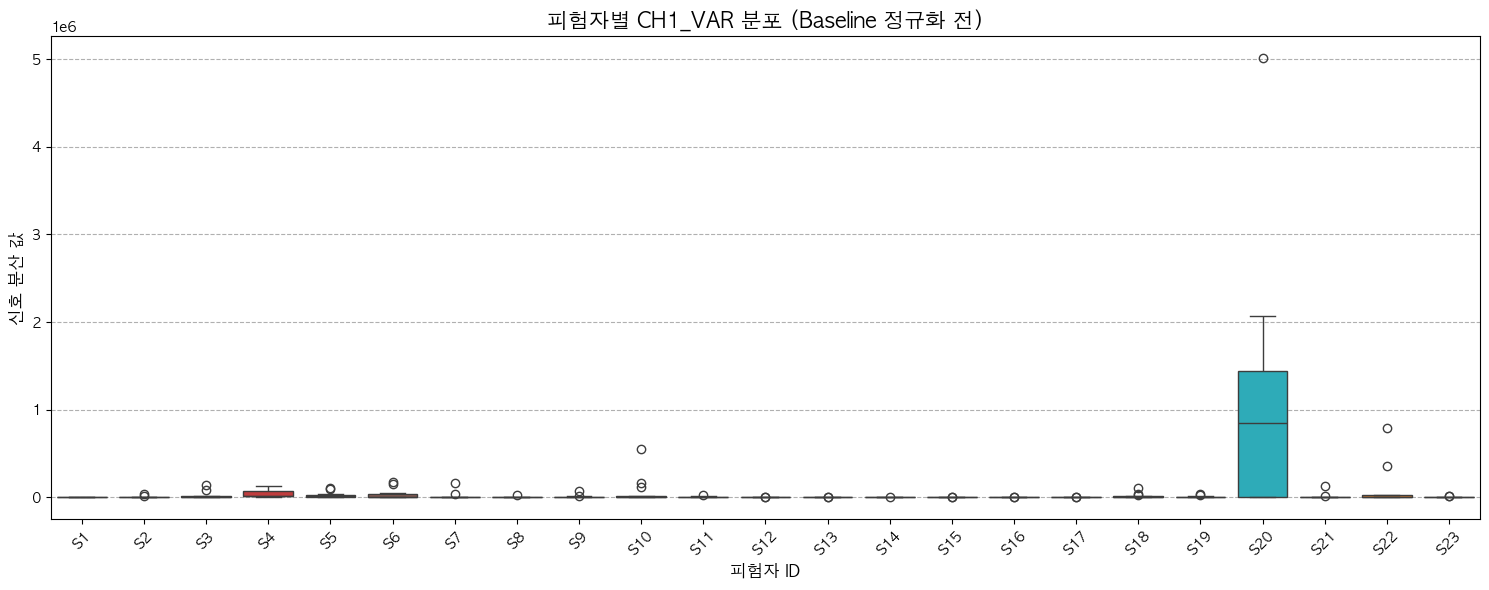

In [49]:
feature_to_plot_var = 'ch1_var'

plt.figure(figsize=(15, 6))

# 피험자 ID별로 해당 특징의 분포를 보여줍니다.
sns.boxplot(
    data=df_final,
    x='subject', # 피험자 ID
    y=feature_to_plot_var,
    palette='tab10'
)

plt.title(f'피험자별 {feature_to_plot_var.upper()} 분포 (Baseline 정규화 전)', fontsize=15)
plt.xlabel('피험자 ID', fontsize=12)
plt.ylabel('신호 분산 값', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

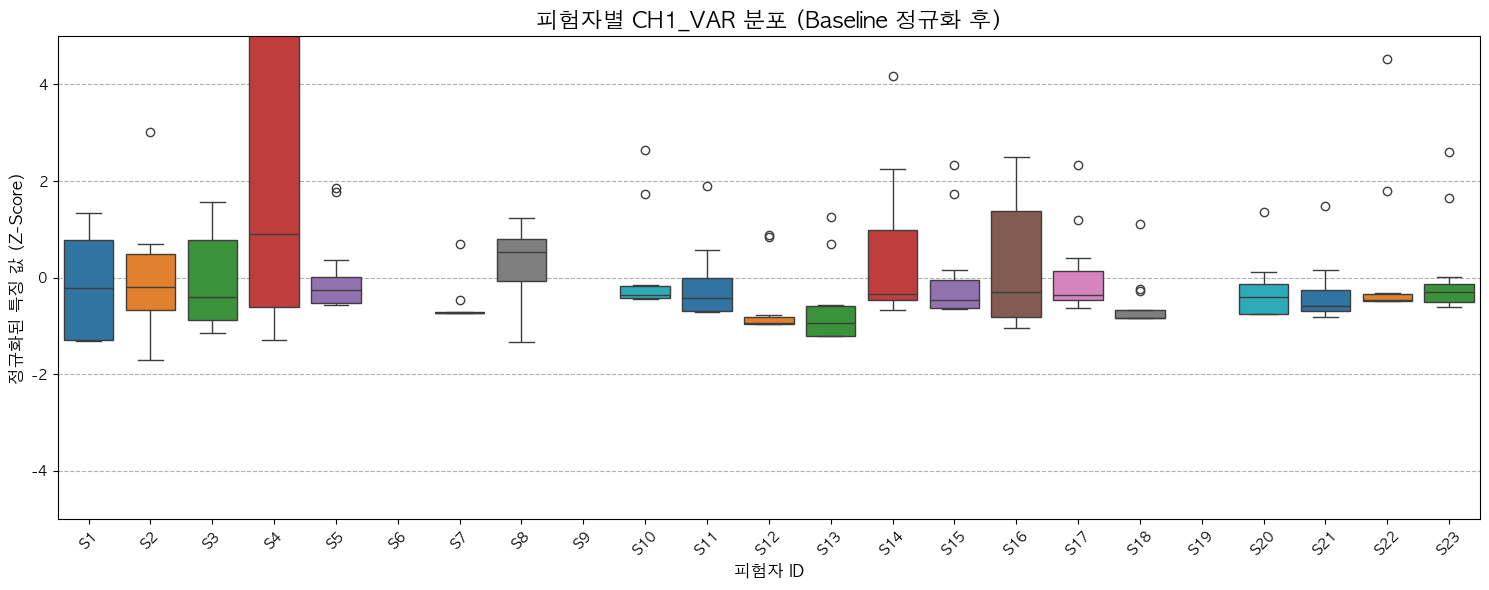

In [50]:
#정규화된 데이터로 새로운 DataFrame 생성
df_normalized = pd.DataFrame(X_final_normalized, columns=X_features)

# 피험자 ID 컬럼 추가 (비교를 위해)
df_normalized['subject'] = df_final['subject'].reset_index(drop=True)


feature_to_plot_var = 'ch1_var'

# 4. 시각화 실행
plt.figure(figsize=(15, 6))

sns.boxplot(
    x='subject',
    y=feature_to_plot_var,
    data=df_normalized,
    palette='tab10'
)

plt.title(f'피험자별 {feature_to_plot_var.upper()} 분포 (Baseline 정규화 후)', fontsize=16)
plt.xlabel('피험자 ID', fontsize=12)
plt.ylabel('정규화된 특징 값 (Z-Score)', fontsize=12) 
plt.ylim(-5, 5)
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# 이 데이터는 LOSO-CV의 첫 번째 훈련 데이터로 이미 준비되어야 합
# (Grid Search 섹션 코드를 실행했다고 가정)

# X_final_normalized: Baseline 정규화된 전체 특징 데이터
# y:스트레스 레이블
# groups:피험자 그룹

# 1. RFE를 위한 데이터 준비 (Grid Search와 동일)

# LOSO-CV의 첫 번째 훈련 데이터를 추출
logo = LeaveOneGroupOut()
first_fold = next(logo.split(X_final_normalized, y, groups=groups))
train_index, _ = first_fold

X_train = X_final_normalized[train_index]
y_train = y[train_index]

 
# 훈련 데이터 NaN 처리(모델 7에 맞춰 Median) 
imputer_grid = SimpleImputer(strategy='median')
X_train_imputed = imputer_grid.fit_transform(X_train)

# RFE 실행 (20개 특징 선택)
N_FEATURES_TO_SELECT_20 = 20
rfe_base_model= LogisticRegression(max_iter=5000, solver='liblinear', random_state=42)

rfe_selector = RFE(estimator=rfe_base_model, n_features_to_select=N_FEATURES_TO_SELECT_20, step=1)
rfe_selector.fit(X_train_imputed, y_train)

# 2. 특징 중요도 추출 및 시각화 

# 선택된 특징의 마스크(Boolean Array)를 사용하여 특징 이름 추출
selected_features_mask = rfe_selector.support_
# X_features는 특징 이름 리스트 (ch1_mean, ch1_std, ...)
selected_feature_names = [X_features[i] for i, is_selected in enumerate(selected_features_mask) if is_selected]

# RFE 모델의 계수(Coefficient) 추출
# RFE는 기본 모델을 사용하여 특징의 중요도를 평가합
feature_coefficients = rfe_selector.estimator_.coef_[0]

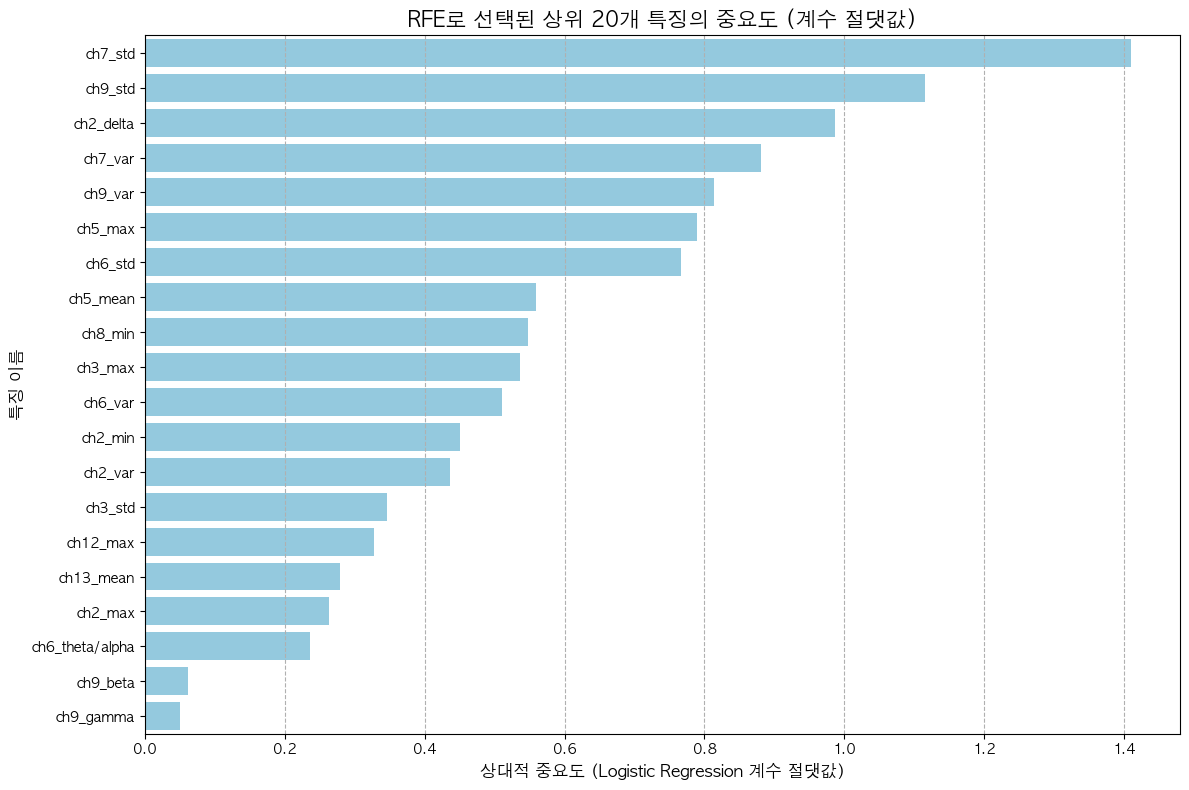

In [52]:
# 시각화
# DataFrame 생성 및 정렬
df_importance = pd.DataFrame({
    'Feature': selected_feature_names,
    'Coefficient_Abs': np.abs(feature_coefficients), # 절댓값 사용(양의/음의 상관 관계 크기)
    'Coefficient': feature_coefficients
})

# 중요도(계수 절댓값) 기준으로 내림차순 정렬
df_importance = df_importance.sort_values(by='Coefficient_Abs', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(
    x='Coefficient_Abs',
    y='Feature',
    data=df_importance,
    color='skyblue'
)

plt.title(f'RFE로 선택된 상위 {N_FEATURES_TO_SELECT_20}개 특징의 중요도 (계수 절댓값)', fontsize=15)
plt.xlabel('상대적 중요도 (Logistic Regression 계수 절댓값)', fontsize=12)
plt.ylabel('특징 이름', fontsize=12)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

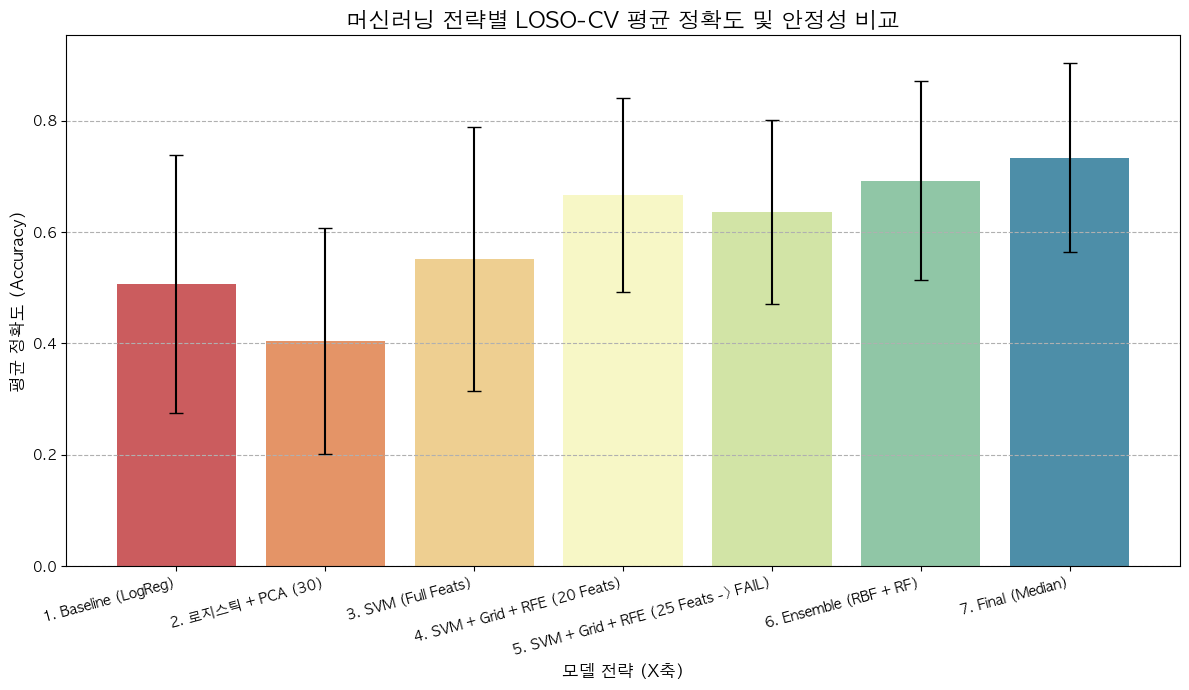

In [54]:
# df_results는 'Strategy', 'Accuracy', 'Std Dev' 등의 컬럼을 포함
#'Accuracy','Sta Dev'를 실수로 변환

df_results['Accuracy']=pd.to_numeric(df_results['Accuracy'], errors='coerce')
df_results['Std Dev']=pd.to_numeric(df_results['Std Dev'], errors='coerce')
plt.figure(figsize=(12, 7))

# 평균 정확도를 막대 그래프로 시각화
sns.barplot(
    x='Strategy',
    y='Accuracy',
    data=df_results,
    palette='Spectral' # 다양한 색상 팔레트 사용
)

# LOSO-CV의 표준 편차(Std Dev)를 오차 막대(Error Bar)로 추가
# capsize를 사용하여 오차 막대의 끝에 캡을 표시
plt.errorbar(
    x=df_results['Strategy'],
    y=df_results['Accuracy'],
    yerr=df_results['Std Dev'],
    fmt='none', # 막대 위에 선을 그리지 않음
    c='black', 
    capsize=5, # 오차 막대 끝에 캡 크기
    elinewidth=1.5 # 오차 막대 선 굵기
)

# 레이블 및 제목 설정
plt.title('머신러닝 전략별 LOSO-CV 평균 정확도 및 안정성 비교', fontsize=16)
plt.xlabel('모델 전략 (X축)', fontsize=12)
plt.ylabel('평균 정확도 (Accuracy)', fontsize=12)
plt.ylim(0,df_results['Accuracy'].max() * 1.3) # Y축 범위 조절
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=15, ha='right') # 전략 이름이 길 경우 기울이기
plt.tight_layout()
plt.show()

In [56]:
#모델7의 run_loso_test결과에 대한 리스트를 1차원 배열로 묶음
y_true_cm=np.concatenate(y_true)
y_pred_cm=np.concatenate(y_pred)
y_pred_cm

array([1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0.,
       1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1.,
       1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1.,
       1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0.,
       1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
       0., 0., 0., 1., 1.

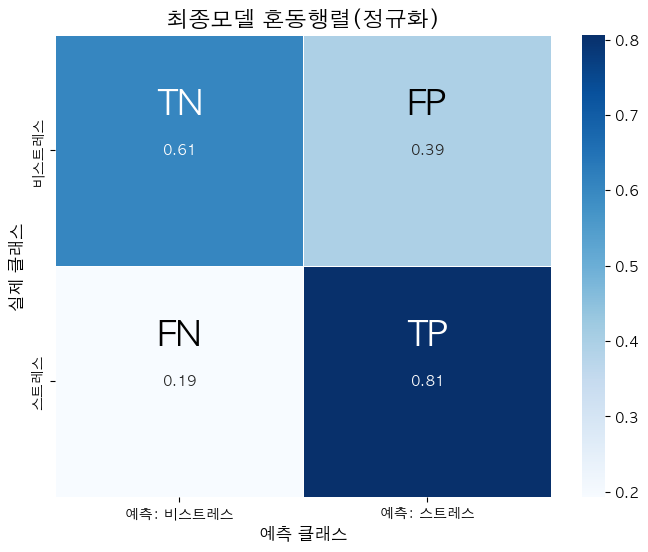

'결과 분석: 비스트레스 상태를 높은 확률로 예측 (TN)\n스트레스 상태를 높은확률로 정확하게 예측(TP) \n실제 비스트레스를 스트레스로 분류 할 확률(FP) \n실제 스트레스를 비스트레스로 분류 할 확률(FN) \n\n*비율은 변동 될 수 있으니 그래프에 맞게 쓰세요.\nrecall(재현율) TP/(TP+FN)=0.8/(0.8+0.2)\nprecision(정밀도) TP/TP+FP=0.8/(0.8+0.41)\nf1-score  (정밀도와 재현율의 조화 평균) (2xrecallxprecision)/(recall+precision) \n'

In [60]:
from sklearn.metrics import confusion_matrix
#최종 모델에서 오차 유형을 보기위해 혼동 행렬 생성
cm=confusion_matrix(y_true_cm, y_pred_cm,labels=[0,1]) #비스트레스,스트레스
#혼동행렬 정규화
cm_nom=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]


plt.figure(figsize=(8,6))

sns.heatmap(cm_nom,
           annot=True,
           fmt='.2f',
           cmap='Blues',
           linewidths=0.5,
           cbar=True,
           yticklabels=['비스트레스','스트레스'],
           xticklabels=['예측: 비스트레스','예측: 스트레스'])

class_labels = [['TN', 'FP'], ['FN', 'TP']]

for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.5 - 0.2, # 셀 중앙 좌표 계산
                 class_labels[i][j], 
                 fontsize=24, 
                 color='white' if cm_nom[i,j]>0.5 else 'black', # 색상을 동적으로 변경
                 ha='center', va='center', # 중앙 정렬
                 fontweight='bold')

plt.title('최종모델 혼동행렬(정규화)',fontsize=16)
plt.ylabel('실제 클래스',fontsize=12)
plt.xlabel('예측 클래스',fontsize=12)
plt.show()

'''결과 분석: 비스트레스 상태를 높은 확률로 예측 (TN)
스트레스 상태를 높은확률로 정확하게 예측(TP) 
실제 비스트레스를 스트레스로 분류 할 확률(FP) 
실제 스트레스를 비스트레스로 분류 할 확률(FN) 

*비율은 변동 될 수 있으니 그래프에 맞게 쓰세요.
recall(재현율) TP/(TP+FN)=0.8/(0.8+0.2)
precision(정밀도) TP/TP+FP=0.8/(0.8+0.41)
f1-score  (정밀도와 재현율의 조화 평균) (2xrecallxprecision)/(recall+precision) 
'''

In [61]:
y_scores_au=np.concatenate(y_scores)

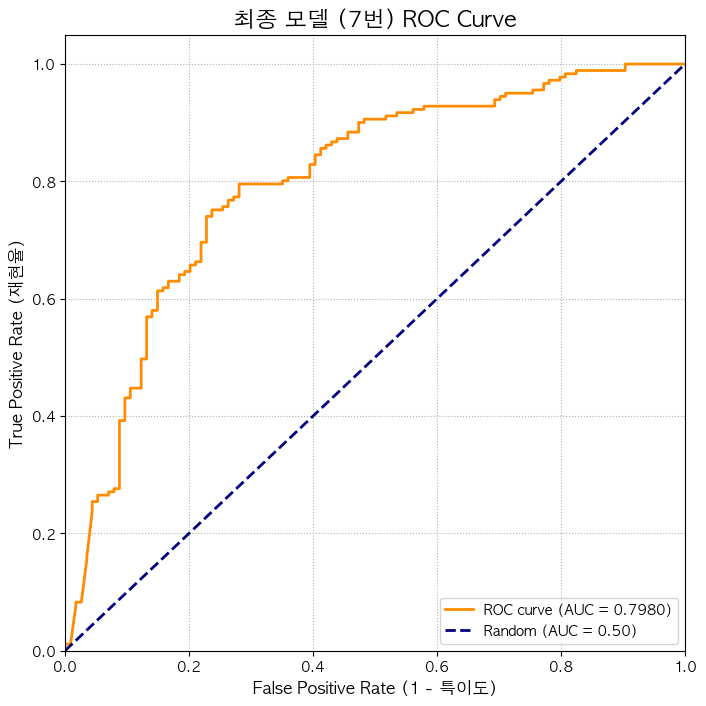

In [59]:
#auroc 시각화
from sklearn.metrics import roc_curve, auc
#  ROC Curve 데이터 계산
# fpr:False Positive Rate, tpr:True Positive Rate
fpr, tpr, thresholds = roc_curve(y_true_cm, y_scores_au)

# AUC (Area Under the Curve) 값 계산
roc_auc = auc(fpr, tpr)

# 시각화
plt.figure(figsize=(8, 8))

# ROC Curve 플롯
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')

# 무작위 분류(Random Classifier) 선
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - 특이도)', fontsize=12)
plt.ylabel('True Positive Rate (재현율)', fontsize=12)
plt.title('최종 모델 (7번) ROC Curve', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':')
plt.show()